<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="images/upct_logo.png" alt="UPCT" style="height:145px; width:auto;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="images/umu_logo.png" alt="UMU" style="height:200px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 4: Codificadores automáticos
### **Sesión 2/3: Autocodificadores convolucionales**

**Autores**: Juan Morales Sánchez, Antonio Martínez Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya

___

### Objetivos

- Analizar la representación latente y el concepto de *autoencoder* disperso.
- Comprender la arquitectura de los *autoencoders* convolucionales.
- Diseño de un *autoencoder* convolucional.
- Evaluar la calidad de la reconstrucción y la compresión en el espacio latente
- Aplicación al coloreado de imágenes de nivel de gris.

### Contenidos
- [El dataset CelebA](#dataset)
- [*Autoencoder* convolucional](#conv_autoencoder)
- [Ejercicios](#ejercicios)

### Requisitos 
<a class='anchor' id='requisitos'></a>

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (*Machine Learning*)
- [Scikit-image](https://pypi.org/project/scikit-image/) (*Image Processing*)
- [Matplotlib](https://pypi.org/project/matplotlib/) y [Seaborn](https://pypi.org/project/seaborn/) (visualización de datos)
- [Tensorflow](https://www.tensorflow.org/) 2.x que incluye a [Keras](https://www.tensorflow.org/guide/keras) 2.x (*Deep Learning*)



<a class='anchor' id='dataset'></a>

## El dataset CelebA

En esta sesión de prácticas emplearemos el dataset [50k Celeba Dataset 64x64](https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64) construido con 50.000 imágenes de caras centradas y recortadas a un tamaño reducido de 64x64. Se trata de un subcojunto de imágenes procesadas, extraídas del extenso dataset *Large-scale CelebFaces Attributes* [(CelebA)](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html), con el objetivo de reducir las necesidades de cómputo cuando se experimenta con los *autoencoders*. El código que se presenta a continuación carga únicamente 10.000 imágenes, suficientes para la mayoría de los experimentos. No obstante, este número de imágenes puede aumentarse modificando la variable ```NUMBER_OF_IMAGES```. Se generan las imágenes tanto en color (```images```) conmo en escala de grises (```images_gray```).

In [1]:
# Importar librerías necesarias
import os
import numpy as np
from tensorflow.keras.utils import get_file
from tensorflow.image import rgb_to_grayscale
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Descargar el dataset
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/therealcyberlord/50k-celeba-dataset-64x64"

dataset_path = get_file(origin=dataset_url, extract=True)

base_dir = os.path.join(os.path.dirname(dataset_path), '50k-celeba-dataset-64x64', '50k')
try:
    os.listdir(base_dir)
except:
    base_dir = os.path.join(os.path.dirname(dataset_path), '50k')

print(f"Leyendo imágenes desde {base_dir:s}")

# Preparar listas para imágenes
NUMBER_OF_IMAGES = 10000 # <= 50000
IMAGE_DIM = (64, 64)

images = np.empty((NUMBER_OF_IMAGES, *IMAGE_DIM, 3))
images_gray = np.empty((NUMBER_OF_IMAGES, *IMAGE_DIM, 1))
for i, img_file in enumerate(os.listdir(base_dir)):
    if (i > 0) and (i%1000 == 0):
        print(f"Cargadas {i:d} imágenes...")
    if i == NUMBER_OF_IMAGES:
        break
    img_path = os.path.join(base_dir, img_file)
    img = load_img(img_path, target_size=IMAGE_DIM, color_mode='rgb')   # Redimensionar imágenes
    images[i] = img_to_array(img) / 255.0            # Normalizar a [0, 1]
    images_gray[i] = rgb_to_grayscale(images[i])

Leyendo imágenes desde C:\Users\cgeal\.keras\datasets\50k-celeba-dataset-64x64\50k
Cargadas 1000 imágenes...
Cargadas 2000 imágenes...
Cargadas 3000 imágenes...
Cargadas 4000 imágenes...
Cargadas 5000 imágenes...
Cargadas 6000 imágenes...
Cargadas 7000 imágenes...
Cargadas 8000 imágenes...
Cargadas 9000 imágenes...
Cargadas 10000 imágenes...


<a class='anchor' id='conv_autoencoder'></a>

## *Autoencoder* convolucional

Continuando con el trabajo de la sesión anterior, en esta sesión se experimentará con un *autoencoder* convolucional (CAE), en el que la idea básica radica en reemplazar las capas totalmente conectadas (empleadas en la sesión anterior) por capas convolucionales, lo que generalmente permite capturar las características geométricas o espaciales, así como reducir el número de parámetros, lo que puede conducir a una mayor eficiencia y a un menor riesgo de sobreajuste. A grandes rasgos y para dimensión 2D de los datos de entrada (imágenes), la arquitectura de red sería similar a la mostrada en la siguiente figura.

<div style="display:flex; justify-content:space-around; align-items:center; padding:5px solid #333333;">
    <a href="https://arc.fiu.edu/projects/artificial-intelligence-for-em-problem-set-dd/attachment/convolutional-autoencoder-cae-architecture/" target="_blank">
    <img src="images/Convolutional-AutoEncoder-CAE-architecture.png" style="height:500px; width:auto;">
</div>

Se denomina campo receptivo a la región del espacio de entrada que después de la operación de convolución afecta, o da como resultado, una característica dentro de un mapa de características a la salida. El campo receptivo es importante tanto en un CAE como en cualquier CNN, porque determina el contexto o la información a la que tiene acceso una neurona a la hora de hacer una predicción. El campo receptivo de una neurona está determinado por el tamaño del núcleo de convolución utilizado en la capa convolucional (```kernel_size```) y por el paso o zancada con la la que se calcula la convolución (```strides```). Un tamaño mayor del núcleo o de la zancada da como resultado un campo receptivo más amplio, lo que significa que cada neurona tiene acceso a más contexto o información de la imagen o mapa de características de entrada. En el codificador, el número de mapas de caractarísticas resultantes en cada nivel (```filters```) suele crecer en potencias de 2 conforme decrecen las dimensiones de la entrada, también en potencias de 2. Y en el decodificador la dimesionalidad de los datos se va recuperando de forma simétrica al codificador hasta la salida.

Por otra parte, existen numerosas variantes o combinaciones de capas accesorias para construir las pirámides de codificación-decodificación. Una de las opciones más habituales para la configuración de cada uno de los niveles de profundidad es la propuesta en esta práctica, en la que construiremos cada nivel convolucional de la pirámide con las siguientes capas (aplicable a imágenes, o datos de entrada 2D):

**Nivel del codificador** (con núcleo de convolución 3x3)
```python
Conv2D(filters, kernel_size = 3, strides = 2, padding = 'same')
BatchNormalization()
LeakyReLU()
```

**Nivel del decodificador** (con núcleo de convolución 3x3)
```python
Conv2DTranspose(filters, kernel_size = 3, strides = 2, padding = 'same')
BatchNormalization()
LeakyReLU()
```

Además de las habituales capas no entrenables de redimensionamiento de datos (```Flatten```, ```Reshape```, etc.) se suele hacer uso de otras capas entrenables y eficientes para enlazar con el espacio latente o con la capa de salida (```SeparableConv2D```, ```Conv2DTranspose```, ```DepthwiseConv2D```, ```GlobalAveragePooling2D```, etc.), evitando casi por completo el uso de capas completamente conectadas.

<a class='anchor' id='ejercicios'></a>

## Ejercicios

**E1:** Partiendo del trabajo de la sesión anterior, diseñe un *autoencoder* totalmente conectado de hasta 3 niveles de profundidad (adicionales al espacio latente), utilizando capas densas de 512, 256 y 128 neuronas con activación ReLU, que pueda funcionar con imágenes (dimensionalidad 2D de los datos de entrada). Experimente con el aumento o disminución en potencias de 2 del número de neuronas de la pirámide, aumentando progresivamente el número de parámatros entrenables. Evalue visual y númericamente los resultados de reconstrucción obtenidos, adaptando las representaciones y métricas propuestas en el enunciado de la sesión 1 de esta práctica. *(Para reducción de cómputo puede utilizar las imágenes en escala de gris)*.

Epoch 1/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0299 - mae: 0.1304 - val_loss: 0.2051 - val_mae: 0.3990
Epoch 2/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0204 - mae: 0.1059 - val_loss: 0.0685 - val_mae: 0.2137
Epoch 3/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0179 - mae: 0.0986 - val_loss: 0.0364 - val_mae: 0.1472
Epoch 4/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0168 - mae: 0.0949 - val_loss: 0.0243 - val_mae: 0.1152
Epoch 5/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0158 - mae: 0.0921 - val_loss: 0.0229 - val_mae: 0.1119
Epoch 6/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0151 - mae: 0.0897 - val_loss: 0.0197 - val_mae: 0.1039
Epoch 7/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0146 - mae: 0.0883 - val_loss: 0.0162 - val_mae: 0.0922
Epoch 8/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0142 - mae: 0.0869 - val_loss: 0.0167 - val_mae: 0.0938
Epoch 9/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - lo

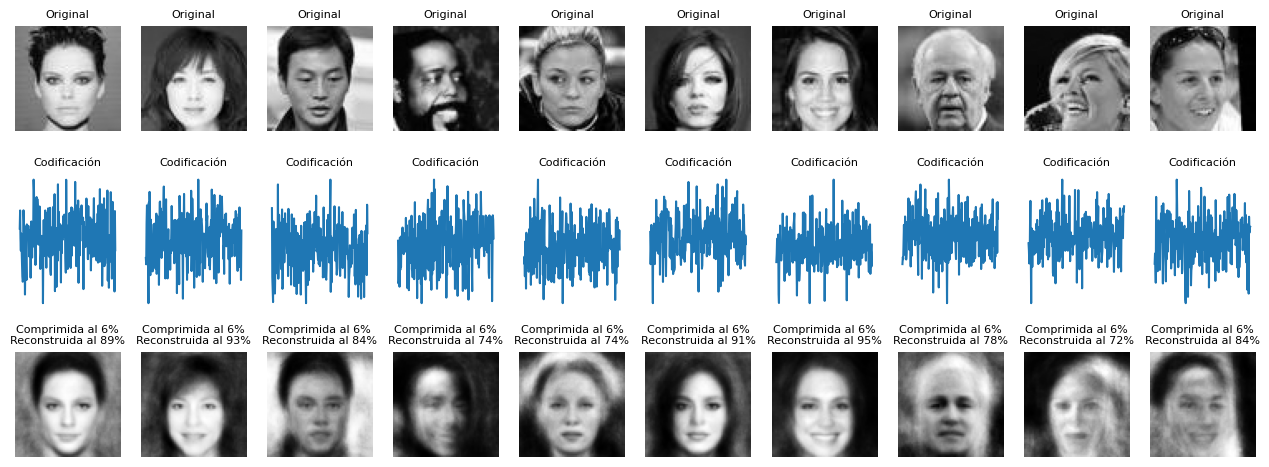

In [2]:
import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score


x_train, x_test = train_test_split(images_gray, test_size=0.15, random_state = 2025)
x_train, x_val = train_test_split(x_train, test_size=0.15, random_state=2025)
# Codificador
IMAGE_SHAPE = x_train.shape[1:]
input_dim = int(np.prod(IMAGE_SHAPE))


latent_dim = 256

input = keras.layers.Input(shape=IMAGE_SHAPE)                   # Nivel 0 (espacio base)
x = keras.layers.Flatten()(input)
x = keras.layers.Dense(512)(x)     # Nivel 1 (capa oculta)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)


x = keras.layers.Dense(256)(x)         # Nivel 2	(capa oculta)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)


x = keras.layers.Dense(128)(x)         # Nivel 3	(capa oculta)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)


encoded_z = keras.layers.Dense(latent_dim)(x)                   # Nivel 4 (espacio latente)
encoder = keras.Model(input, encoded_z)                 # Modelo codificador: datos de entrada -> codificación en espacio latente


# Decodificador   
#                                              
x = keras.layers.Dense(128)(encoded_z)         # Nivel 3	(capa oculta)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)		

x = keras.layers.Dense(256)(x)         # Nivel 2	(capa oculta)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)   

x = keras.layers.Dense(512)(x)         # Nivel 1	(capa oculta)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)   

# Capa de salida

x = keras.layers.Dense(input_dim, activation='sigmoid')(x)          # Nivel 1	(capa oculta)	

reconstructed = keras.layers.Reshape(IMAGE_SHAPE)(x)           # Nivel 0 (espacio base)

decoder = keras.Model(encoded_z, reconstructed)                 # Modelo decodificador: codificación en espacio latente -> datos reconstruidos

# Autocodificador
autoencoder = keras.Model(input, reconstructed)

# Entrenamos el modelo

from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',   # si tu modelo compila con metrics=['mae']
    patience=12,
    min_delta=1e-4,
    restore_best_weights=True,
    mode='min',
    verbose=1
)



autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = autoencoder.fit(x_train, x_train,
    validation_data = (x_val,x_val),
    batch_size=128,
    epochs = 300,
	callbacks = [early_stopping])

encoded_images = encoder.predict(x_test, verbose = 0 )
decoded_images = decoder.predict(encoded_images, verbose = 0)

fig, axes = plt.subplots(3,10, figsize =(16,6))
for i in range(10):
	axes[0,i].imshow(x_test[i], cmap='gray')
	axes[0,i].axis('off')
	axes[0,i].set_title(f'Original', fontsize = 8)
	axes[1,i].plot(encoded_images[i])
	axes[1,i].axis('off')
	axes[1,i].set_title(f'Codificación', fontsize = 8)
	axes[2,i].imshow(decoded_images[i],cmap = 'gray')
	axes[2,i].axis('off')
	r2 = r2_score(x_test[i].flatten(), decoded_images[i].flatten())
	axes[2,i].set_title(f'Comprimida al {latent_dim/np.prod(IMAGE_SHAPE)*100:.0f}%\nReconstruida al {r2*100:.0f}%', fontsize = 8)

plt.show()

**E2:** Para obtener un *sparse autoencoder* y observar sus consecuencias en cuanto a codificación y reconstrucción, aplique una regularización de actividad L1 en la capa densa del espacio latente, así como activación ```ReLU```. Analice los resultados obtenidos en la codificación latente en comparación con los del ejercicio E1. Comente la diferencia observada en la reconstrucción y el espacio latente (calidad de reconstrucción, coeficientes no nulos obtenidos en el espacio latente, compresión efectiva de la codificación, etc.). *(Para reducción de cómputo puede utilizar las imágenes en escala de gris)*

E1 - Dense Autoencoder:
  Sparsity: 0.00% (coeficientes nulos)
  Promedio coeficientes no nulos por imagen: 256/256
  R² reconstrucción (promedio): 80.36%

E2 - Sparse Autoencoder (L1):
  Sparsity: 97.89% (coeficientes nulos)
  Promedio coeficientes no nulos por imagen: 5/256
  R² reconstrucción (promedio): 53.86%



C:\Users\cgeal\AppData\Local\Temp\ipykernel_21716\1517541359.py:141: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot([non_zero_E1, non_zero_E2], labels=['E1\n(Dense)', 'E2\n(Sparse L1)'], patch_artist=True)
C:\Users\cgeal\AppData\Local\Temp\ipykernel_21716\1517541359.py:148: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot([r2_scores_E1, r2_scores_E2], labels=['E1\n(Dense)', 'E2\n(Sparse L1)'], patch_artist=True)


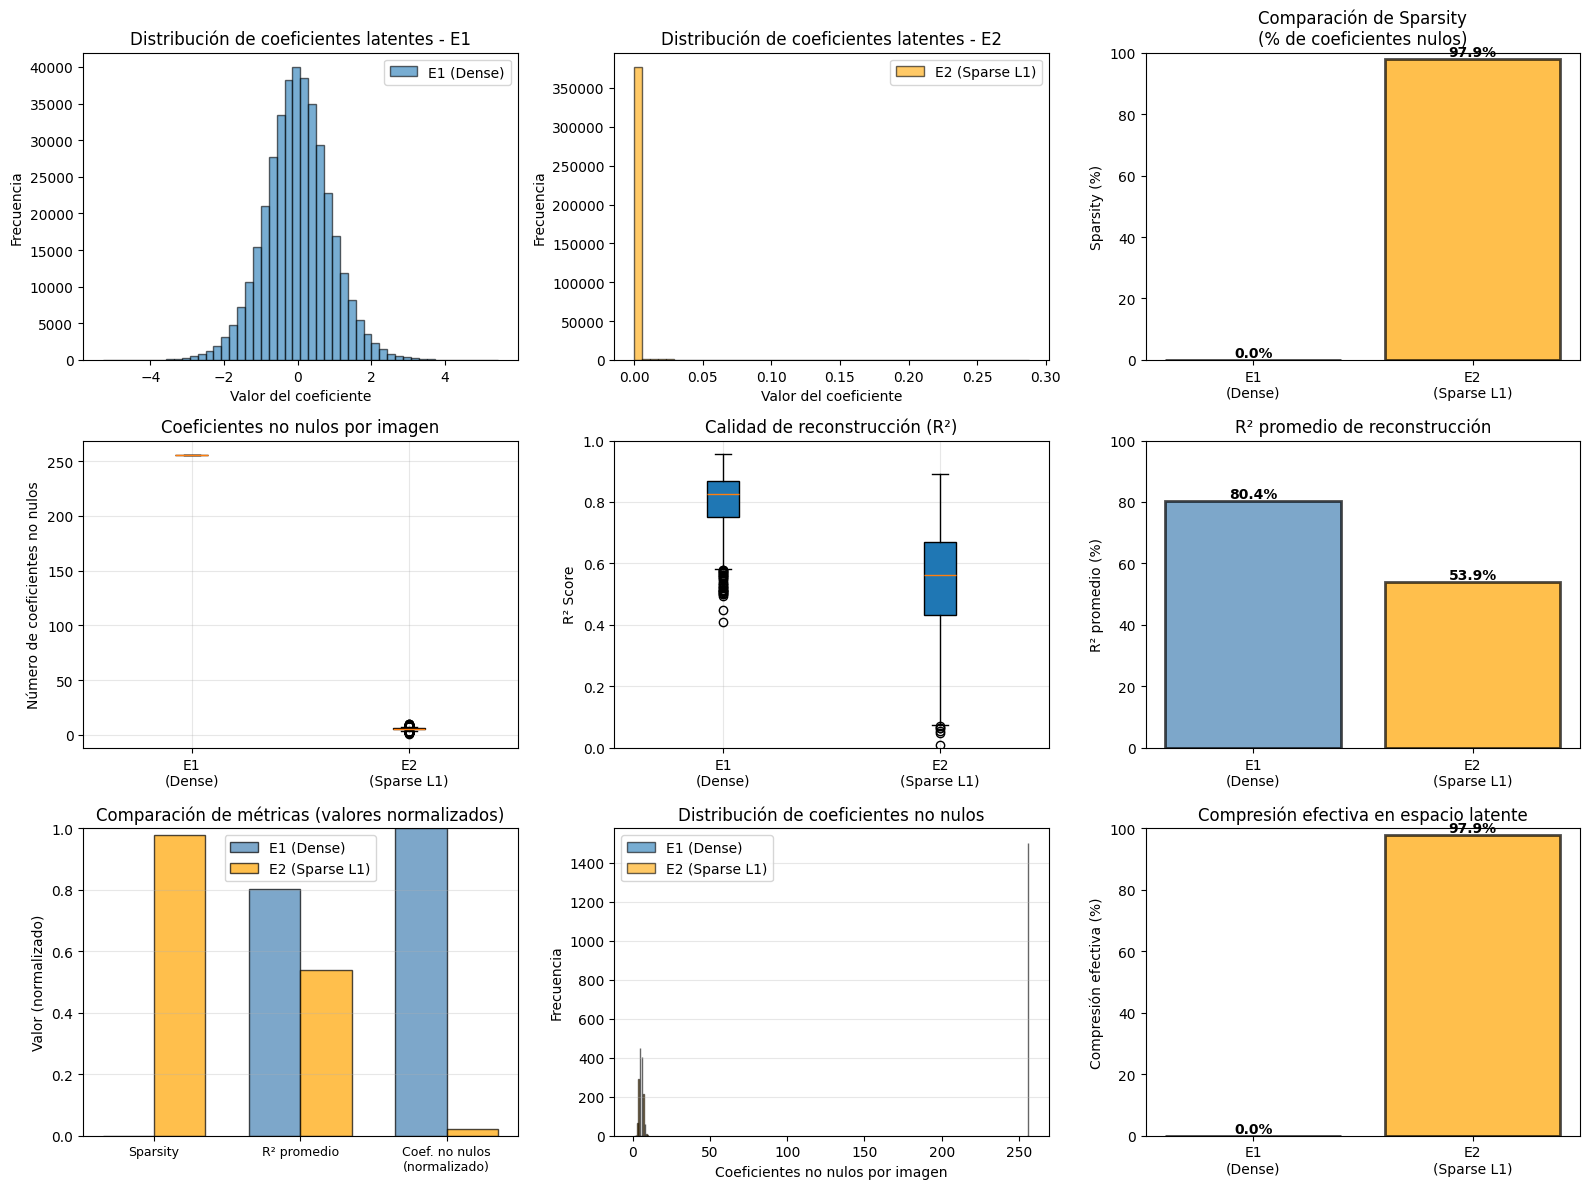

RESUMEN COMPARATIVO E1 vs E2
Métrica                                  E1 (Dense)      E2 (Sparse L1) 
------------------------------------------------------------
Sparsity (%)                                       0.00%          97.89%
Coef. no nulos (promedio)                           256              5
R² reconstrucción (promedio %)                    80.36%          53.86%
Compresión efectiva (%)                            0.00%          97.89%
Nº parámetros encoder                           2298496        2298496


In [3]:
# ============= COMPARACIÓN E1 vs E2 =============
# Guardar datos del E1 (Dense Autoencoder)
encoded_images_E1 = encoded_images.copy()
decoded_images_E1 = decoded_images.copy()
encoder_E1 = encoder
decoder_E1 = decoder
autoencoder_E1 = autoencoder

# Calcular métricas del E1
r2_scores_E1 = []
for i in range(len(x_test)):
    r2 = r2_score(x_test[i].flatten(), decoded_images_E1[i].flatten())
    r2_scores_E1.append(r2)

sparsity_E1 = np.sum(encoded_images_E1 == 0) / encoded_images_E1.size
non_zero_E1 = np.count_nonzero(encoded_images_E1, axis=1)

print(f"E1 - Dense Autoencoder:")
print(f"  Sparsity: {sparsity_E1*100:.2f}% (coeficientes nulos)")
print(f"  Promedio coeficientes no nulos por imagen: {np.mean(non_zero_E1):.0f}/{latent_dim}")
print(f"  R² reconstrucción (promedio): {np.mean(r2_scores_E1)*100:.2f}%")
print()

# ============= Construir E2: Sparse Autoencoder con L1 =============
input_E2 = keras.layers.Input(shape=IMAGE_SHAPE)
x = keras.layers.Flatten()(input_E2)
x = keras.layers.Dense(512)(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Dense(256)(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Dense(128)(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

# DIFERENCIA EN E2: Activación ReLU + Regularización L1
encoded_z_E2 = keras.layers.Dense(
    latent_dim,
    activation='relu',
    activity_regularizer=keras.regularizers.L1(1e-4)  # Regularización L1
)(x)

encoder_E2 = keras.Model(input_E2, encoded_z_E2)

# Decodificador
x = keras.layers.Dense(128)(encoded_z_E2)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Dense(256)(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Dense(512)(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Dense(input_dim, activation='sigmoid')(x)
reconstructed_E2 = keras.layers.Reshape(IMAGE_SHAPE)(x)

decoder_E2 = keras.Model(encoded_z_E2, reconstructed_E2)
autoencoder_E2 = keras.Model(input_E2, reconstructed_E2)

# Entrenar E2
autoencoder_E2.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stopping_E2 = EarlyStopping(
    monitor='val_loss',
    patience=12,
    min_delta=1e-4,
    restore_best_weights=True,
    mode='min',
    verbose=0
)

history_E2 = autoencoder_E2.fit(
    x_train, x_train,
    validation_data=(x_val, x_val),
    batch_size=128,
    epochs=300,
    callbacks=[early_stopping_E2],
    verbose=0
)

# Generar predicciones E2
encoded_images_E2 = encoder_E2.predict(x_test, verbose=0)
decoded_images_E2 = decoder_E2.predict(encoded_images_E2, verbose=0)

# Calcular métricas del E2
r2_scores_E2 = []
for i in range(len(x_test)):
    r2 = r2_score(x_test[i].flatten(), decoded_images_E2[i].flatten())
    r2_scores_E2.append(r2)

sparsity_E2 = np.sum(encoded_images_E2 == 0) / encoded_images_E2.size
non_zero_E2 = np.count_nonzero(encoded_images_E2, axis=1)

print(f"E2 - Sparse Autoencoder (L1):")
print(f"  Sparsity: {sparsity_E2*100:.2f}% (coeficientes nulos)")
print(f"  Promedio coeficientes no nulos por imagen: {np.mean(non_zero_E2):.0f}/{latent_dim}")
print(f"  R² reconstrucción (promedio): {np.mean(r2_scores_E2)*100:.2f}%")
print()

# ============= GRÁFICAS COMPARATIVAS =============
fig = plt.figure(figsize=(16, 12))

# 1. Distribución de coeficientes latentes
ax1 = plt.subplot(3, 3, 1)
ax1.hist(encoded_images_E1.flatten(), bins=50, alpha=0.6, label='E1 (Dense)', edgecolor='black')
ax1.set_xlabel('Valor del coeficiente')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de coeficientes latentes - E1')
ax1.legend()

ax2 = plt.subplot(3, 3, 2)
ax2.hist(encoded_images_E2.flatten(), bins=50, alpha=0.6, label='E2 (Sparse L1)', color='orange', edgecolor='black')
ax2.set_xlabel('Valor del coeficiente')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de coeficientes latentes - E2')
ax2.legend()

# 2. Sparsity comparison
ax3 = plt.subplot(3, 3, 3)
models = ['E1\n(Dense)', 'E2\n(Sparse L1)']
sparsities = [sparsity_E1*100, sparsity_E2*100]
colors = ['steelblue', 'orange']
bars = ax3.bar(models, sparsities, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('Sparsity (%)')
ax3.set_title('Comparación de Sparsity\n(% de coeficientes nulos)')
ax3.set_ylim([0, 100])
for bar, sp in zip(bars, sparsities):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{sp:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Coeficientes no nulos por imagen
ax4 = plt.subplot(3, 3, 4)
ax4.boxplot([non_zero_E1, non_zero_E2], labels=['E1\n(Dense)', 'E2\n(Sparse L1)'], patch_artist=True)
ax4.set_ylabel('Número de coeficientes no nulos')
ax4.set_title('Coeficientes no nulos por imagen')
ax4.grid(True, alpha=0.3)

# 4. R² de reconstrucción (distribución)
ax5 = plt.subplot(3, 3, 5)
ax5.boxplot([r2_scores_E1, r2_scores_E2], labels=['E1\n(Dense)', 'E2\n(Sparse L1)'], patch_artist=True)
ax5.set_ylabel('R² Score')
ax5.set_title('Calidad de reconstrucción (R²)')
ax5.set_ylim([0, 1])
ax5.grid(True, alpha=0.3)

# 5. R² promedio
ax6 = plt.subplot(3, 3, 6)
r2_means = [np.mean(r2_scores_E1)*100, np.mean(r2_scores_E2)*100]
bars = ax6.bar(models, r2_means, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax6.set_ylabel('R² promedio (%)')
ax6.set_title('R² promedio de reconstrucción')
ax6.set_ylim([0, 100])
for bar, r2m in zip(bars, r2_means):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{r2m:.1f}%', ha='center', va='bottom', fontweight='bold')

# 7. Comparación de modelos (métricas normalizadas)
ax7 = plt.subplot(3, 3, 7)
metrics = ['Sparsity', 'R² promedio', 'Coef. no nulos\n(normalizado)']
E1_metrics = [sparsity_E1, np.mean(r2_scores_E1), np.mean(non_zero_E1)/latent_dim]
E2_metrics = [sparsity_E2, np.mean(r2_scores_E2), np.mean(non_zero_E2)/latent_dim]

x_pos = np.arange(len(metrics))
width = 0.35

bars1 = ax7.bar(x_pos - width/2, E1_metrics, width, label='E1 (Dense)', color='steelblue', alpha=0.7, edgecolor='black')
bars2 = ax7.bar(x_pos + width/2, E2_metrics, width, label='E2 (Sparse L1)', color='orange', alpha=0.7, edgecolor='black')

ax7.set_ylabel('Valor (normalizado)')
ax7.set_title('Comparación de métricas (valores normalizados)')
ax7.set_xticks(x_pos)
ax7.set_xticklabels(metrics, fontsize=9)
ax7.legend()
ax7.set_ylim([0, 1])
ax7.grid(True, alpha=0.3, axis='y')

# 8. Histograma de no nulos
ax8 = plt.subplot(3, 3, 8)
ax8.hist(non_zero_E1, bins=20, alpha=0.6, label='E1 (Dense)', edgecolor='black')
ax8.hist(non_zero_E2, bins=20, alpha=0.6, label='E2 (Sparse L1)', color='orange', edgecolor='black')
ax8.set_xlabel('Coeficientes no nulos por imagen')
ax8.set_ylabel('Frecuencia')
ax8.set_title('Distribución de coeficientes no nulos')
ax8.legend()
ax8.grid(True, alpha=0.3, axis='y')

# 9. Compresión efectiva
ax9 = plt.subplot(3, 3, 9)
compression_E1 = (1 - np.mean(non_zero_E1)/latent_dim) * 100
compression_E2 = (1 - np.mean(non_zero_E2)/latent_dim) * 100
compressions = [compression_E1, compression_E2]
bars = ax9.bar(models, compressions, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax9.set_ylabel('Compresión efectiva (%)')
ax9.set_title('Compresión efectiva en espacio latente')
ax9.set_ylim([0, 100])
for bar, comp in zip(bars, compressions):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height,
            f'{comp:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Resumen estadístico
print("="*60)
print("RESUMEN COMPARATIVO E1 vs E2")
print("="*60)
print(f"{'Métrica':<40} {'E1 (Dense)':<15} {'E2 (Sparse L1)':<15}")
print("-"*60)
print(f"{'Sparsity (%)':<40} {sparsity_E1*100:>14.2f}% {sparsity_E2*100:>14.2f}%")
print(f"{'Coef. no nulos (promedio)':<40} {np.mean(non_zero_E1):>14.0f} {np.mean(non_zero_E2):>14.0f}")
print(f"{'R² reconstrucción (promedio %)':<40} {np.mean(r2_scores_E1)*100:>14.2f}% {np.mean(r2_scores_E2)*100:>14.2f}%")
print(f"{'Compresión efectiva (%)':<40} {compression_E1:>14.2f}% {compression_E2:>14.2f}%")
print(f"{'Nº parámetros encoder':<40} {encoder_E1.count_params():>14d} {encoder_E2.count_params():>14d}")
print("="*60)

Por lo tanto, el ejercicio 2 logra una excelente compresión gracias a la esparsidad y los pocos coeficientes no nulos, pero sacrifica la calidad de reconstrucción con 53.48% frente a 81.91% de R2 del ejercicio 1. Por lo tanto una mayor esparsidad, significa una peor recontrucción.

**E3:** A partir del código del ejercicio E1, diseñe ahora un *autoencoder* convolucional de 3 niveles de profundidad, utilizando capas convolucionales 2D de 16, 32 y 64 mapas de características, más el nivel correspondiente al espacio latente de dimensión 1024 (8 x 8 x 16), de acuerdo a lo comentado en el [apartado previo](#conv_autoencoder). Evite utilizar normalización de lotes en las capas de entrada y salida, así como en la correspondiente al espacio latente. Experimente con diferentes dimensiones del espacio latente en el *autoencoder* convolucional, por ejemplo 64, 256, 1024 y 4096, adaptando si es necesario la escalera de codificación-decodificación. Indique las diferencias en cuando a prestaciones con un *autoencoder* totalmente conectado (ejercicio E1): calidad de la reconstrucción conseguida, número de parámetros necesarios en el modelo, tiempo de entrenamiento, etc. *(Para reducción de cómputo puede utilizar las imágenes en escala de gris)*

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 1024)           │        25,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 64, 64, 1)      │        32,961 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,321 (227.82 KB)

 Trainable params: 57,873 (226.07 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.5450 - val_loss: 0.5744 - learning_rate: 5.0000e-04
Epoch 2/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.5293 - val_loss: 0.5233 - learning_rate: 5.0000e-04
Epoch 3/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.5271 - val_loss: 0.5221 - learning_rate: 5.0000e-04
Epoch 4/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.5260 - val_loss: 0.5191 - learning_rate: 5.0000e-04
Epoch 5/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.5252 - val_loss: 0.5215 - learning_rate: 5.0000e-04
Epoch 6/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.5243 - val_loss: 0.5180 - learning_rate: 5.0000e-04
Epoch 7/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.5240 - val_loss: 0.5195 - learning_rate: 5.0000e-04
Epoch 8/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.5235 - val_loss: 0.5174 - learning_rate: 5.0000e-04
Epoch 9/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0

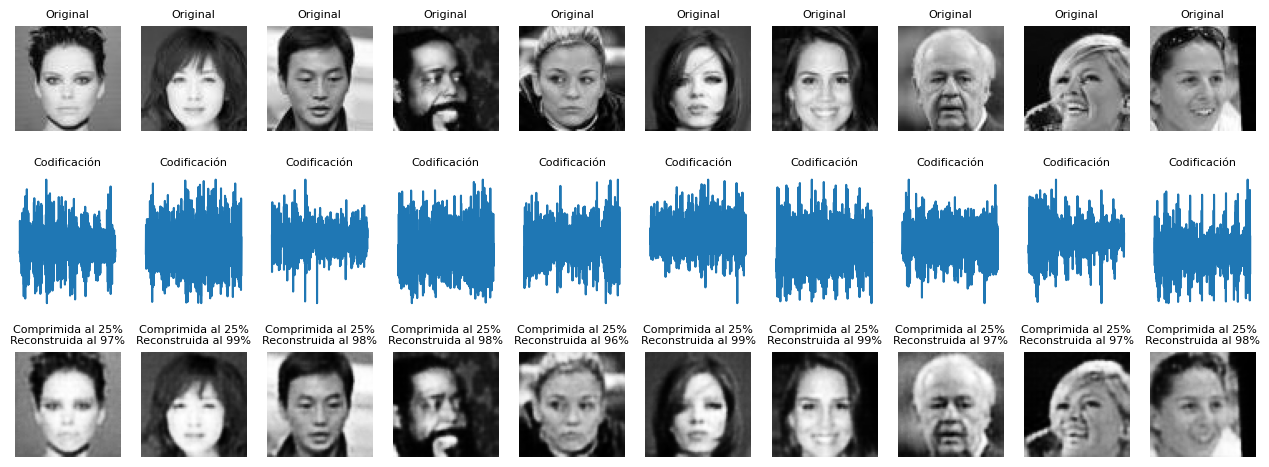

In [4]:
input_shape = x_train.shape[1:]
input_dim = np.prod(input_shape)
latent_dim = 64 * 16

MUL = 8

# Encoder
input_img = keras.layers.Input(shape=(input_shape))                                                         
x = keras.layers.Conv2D(32//2, kernel_size=3, strides=2, padding="same")(input_img)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)
x = keras.layers.Conv2D(64//2, kernel_size=3, strides=2, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)
x = keras.layers.Conv2D(64, kernel_size=3, strides=2, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

encoded_z = keras.layers.SeparableConv2D(latent_dim//64, kernel_size=3, activation='linear', padding="same")(x)
encoded_z = keras.layers.Flatten()(encoded_z)
encoder = keras.Model(input_img, encoded_z, name="Encoder")

# Decoder       

x = keras.layers.Reshape((input_shape[0]//2**3, input_shape[1]//2**3, latent_dim//64))(encoded_z)

x = keras.layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)
x = keras.layers.Conv2DTranspose(64//2, kernel_size=3, strides=2, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)
x = keras.layers.Conv2DTranspose(32//2, kernel_size=3, strides=2, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

reconstructed = keras.layers.Conv2DTranspose(input_shape[-1], kernel_size=3, padding="same", activation='sigmoid')(x)

decoder = keras.Model(encoded_z, reconstructed, name="Decoder")

# Autoencoder completo
autoencoder_input = keras.layers.Input(shape=input_shape)
encoded_repr = encoder(autoencoder_input)
decoded_img = decoder(encoded_repr)

autoencoder = keras.Model(autoencoder_input, decoded_img, name="Autoencoder")

autoencoder.compile(optimizer='adam', loss='mse') 

# Resumen para verificar parámetros
autoencoder.summary()

# Entrenamos el modelo

from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
early_stopping = EarlyStopping(
    monitor='val_loss',   
    patience=15,
    min_delta=1e-3,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)

autoencoder.compile(optimizer=Adam(learning_rate = 5e-4), loss='binary_crossentropy')

history = autoencoder.fit(x_train, x_train,
    validation_data = (x_val,x_val),
    batch_size=16,
    epochs = 100,
	callbacks = [early_stopping, reduce_lr])

encoded_images = encoder.predict(x_test, verbose = 0 )
decoded_images = decoder.predict(encoded_images, verbose = 0)

fig, axes = plt.subplots(3,10, figsize =(16,6))
for i in range(10):
	axes[0,i].imshow(x_test[i], cmap='gray')
	axes[0,i].axis('off')
	axes[0,i].set_title(f'Original', fontsize = 8)
	axes[1,i].plot(encoded_images[i])
	axes[1,i].axis('off')
	axes[1,i].set_title(f'Codificación', fontsize = 8)
	axes[2,i].imshow(decoded_images[i],cmap = 'gray')
	axes[2,i].axis('off')
	r2 = r2_score(x_test[i].flatten(), decoded_images[i].flatten())
	axes[2,i].set_title(f'Comprimida al {latent_dim/np.prod(IMAGE_SHAPE)*100:.0f}%\nReconstruida al {r2*100:.0f}%', fontsize = 8)

plt.show()

Usando las capas convolucionales, el resultado que se obtiene es muchísimo mejor, obteniendo reconstrucciones casi perfectas, con menos resolución que las imágenes originales pero con una calidad que permite identificar perfectamente la cara que se está reconstruyendo.

**E4:** Adapte el código del ejercicio E3 anterior para que funcione con las imágenes RGB en color cargadas del [dataset](#dataset). Experimente con el aumento del número de imágenes de dicho [dataset](#dataset) que se emplean para el entrenamiento, y comente de nuevo de diferencias observadas.

Input shape RGB: (64, 64, 3)
Input dimension: 12288
Latent dimension: 1024

AUTOENCODER RGB - RESUMEN DE ARQUITECTURA


Model: "Autoencoder_RGB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_RGB (Functional)        │ (None, 1024)           │        25,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_RGB (Functional)        │ (None, 64, 64, 3)      │        33,251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,899 (230.07 KB)

 Trainable params: 58,451 (228.32 KB)

 Non-trainable params: 448 (1.75 KB)


Entrenando Autoencoder RGB...
Epoch 1/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - loss: 0.0256 - mae: 0.1140 - val_loss: 0.0743 - val_mae: 0.2340 - learning_rate: 5.0000e-04
Epoch 2/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - loss: 0.0083 - mae: 0.0664 - val_loss: 0.0584 - val_mae: 0.2060 - learning_rate: 5.0000e-04
Epoch 3/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.0064 - mae: 0.0580 - val_loss: 0.0347 - val_mae: 0.1592 - learning_rate: 5.0000e-04
Epoch 4/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0055 - mae: 0.0538 - val_loss: 0.0134 - val_mae: 0.0975 - learning_rate: 5.0000e-04
Epoch 5/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.0048 - mae: 0.0504 - val_loss: 0.0052 - val_mae: 0.0538 - learning_rate: 5.0000e-04
Epoch 6/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.0044 - mae: 0.0484 - val_loss: 0.0043 - val_mae: 0.0473 - learning_rate: 5.0000e-04
Epoch 7/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.0041 - mae

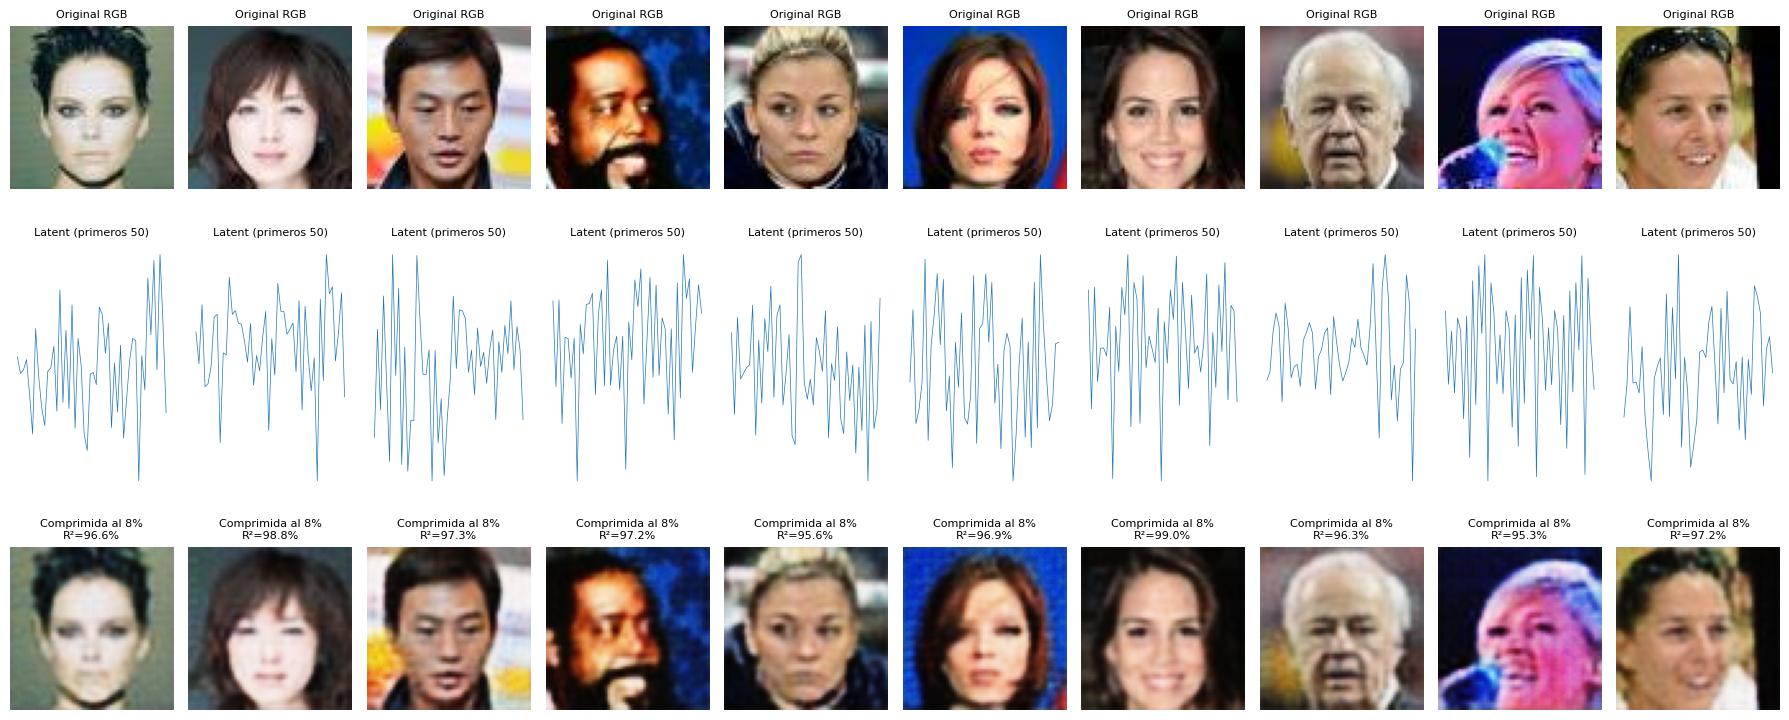


ESTADÍSTICAS - AUTOENCODER RGB
R² medio: 97.11%
R² std: 1.33%
R² mín: 89.60%
R² máx: 99.30%
Número de parámetros: 58,899


In [5]:
# ============= E4: Autoencoder Convolucional con Imágenes RGB =============
# Usa 'images' en lugar de 'images_gray'

x_train_rgb, x_test_rgb = train_test_split(images, test_size=0.15, random_state=2025)
x_train_rgb, x_val_rgb = train_test_split(x_train_rgb, test_size=0.15, random_state=2025)

input_shape_rgb = x_train_rgb.shape[1:]  # (64, 64, 3)
input_dim_rgb = np.prod(input_shape_rgb)
latent_dim_rgb = 64 * 16

print(f"Input shape RGB: {input_shape_rgb}")
print(f"Input dimension: {input_dim_rgb}")
print(f"Latent dimension: {latent_dim_rgb}")

# Encoder (igual que antes, solo cambia input_shape)
input_img_rgb = keras.layers.Input(shape=input_shape_rgb)                                                         
x = keras.layers.Conv2D(16, kernel_size=3, strides=2, padding="same")(input_img_rgb)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Conv2D(32, kernel_size=3, strides=2, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Conv2D(64, kernel_size=3, strides=2, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

encoded_z_rgb = keras.layers.SeparableConv2D(latent_dim_rgb//64, kernel_size=3, activation='linear', padding="same")(x)
encoded_z_rgb = keras.layers.Flatten()(encoded_z_rgb)
encoder_rgb = keras.Model(input_img_rgb, encoded_z_rgb, name="Encoder_RGB")

# Decoder (mismo patrón que el encoder)
x = keras.layers.Reshape((input_shape_rgb[0]//2**3, input_shape_rgb[1]//2**3, latent_dim_rgb//64))(encoded_z_rgb)

x = keras.layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Conv2DTranspose(16, kernel_size=3, strides=2, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

# IMPORTANTE: La salida ahora tiene 3 canales (RGB)
reconstructed_rgb = keras.layers.Conv2DTranspose(input_shape_rgb[-1], kernel_size=3, padding="same", activation='sigmoid')(x)

decoder_rgb = keras.Model(encoded_z_rgb, reconstructed_rgb, name="Decoder_RGB")

# Autoencoder completo
autoencoder_input_rgb = keras.layers.Input(shape=input_shape_rgb)
encoded_repr_rgb = encoder_rgb(autoencoder_input_rgb)
decoded_img_rgb = decoder_rgb(encoded_repr_rgb)

autoencoder_rgb = keras.Model(autoencoder_input_rgb, decoded_img_rgb, name="Autoencoder_RGB")

# Compilar con los parámetros optimizados
autoencoder_rgb.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

# Resumen
print("\n" + "="*60)
print("AUTOENCODER RGB - RESUMEN DE ARQUITECTURA")
print("="*60)
autoencoder_rgb.summary()

# Callbacks
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping_rgb = EarlyStopping(
    monitor='val_loss',
    patience=15,
    min_delta=1e-4,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr_rgb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Entrenar
print("\nEntrenando Autoencoder RGB...")
history_rgb = autoencoder_rgb.fit(
    x_train_rgb, x_train_rgb,
    validation_data=(x_val_rgb, x_val_rgb),
    batch_size=64,
    epochs=300,
    callbacks=[early_stopping_rgb, reduce_lr_rgb],
    verbose=1
)

# Predicciones
encoded_images_rgb = encoder_rgb.predict(x_test_rgb, verbose=0)
decoded_images_rgb = decoder_rgb.predict(encoded_images_rgb, verbose=0)

# Visualización de resultados
fig, axes = plt.subplots(3, 10, figsize=(18, 8))
for i in range(10):
    # Original
    axes[0, i].imshow(x_test_rgb[i])
    axes[0, i].axis('off')
    axes[0, i].set_title('Original RGB', fontsize=8)
    
    # Espacio latente (visualización de primeros valores)
    axes[1, i].plot(encoded_images_rgb[i][:50], linewidth=0.5)  # Primeros 50 coefs
    axes[1, i].axis('off')
    axes[1, i].set_title('Latent (primeros 50)', fontsize=8)
    
    # Reconstruida
    axes[2, i].imshow(decoded_images_rgb[i])
    axes[2, i].axis('off')
    r2 = r2_score(x_test_rgb[i].flatten(), decoded_images_rgb[i].flatten())
    compression = latent_dim_rgb / np.prod(input_shape_rgb) * 100
    axes[2, i].set_title(f'Comprimida al {compression:.0f}%\nR²={r2*100:.1f}%', fontsize=8)

plt.tight_layout()
plt.show()

# Estadísticas
print("\n" + "="*60)
print("ESTADÍSTICAS - AUTOENCODER RGB")
print("="*60)
r2_scores_rgb = [r2_score(x_test_rgb[i].flatten(), decoded_images_rgb[i].flatten()) for i in range(len(x_test_rgb))]
print(f"R² medio: {np.mean(r2_scores_rgb)*100:.2f}%")
print(f"R² std: {np.std(r2_scores_rgb)*100:.2f}%")
print(f"R² mín: {np.min(r2_scores_rgb)*100:.2f}%")
print(f"R² máx: {np.max(r2_scores_rgb)*100:.2f}%")
print(f"Número de parámetros: {autoencoder_rgb.count_params():,}")
print("="*60)